# Tuning playground

In [1]:
%matplotlib widget
import matplotlib.pyplot as plt
import math
import numpy as np
import jax.numpy as jnp
from jax import grad
from random import random

In [2]:
LEARNING_RATE = 1e-4
DECAY = 0.9
MOMENTUM = 0.7

In [3]:
# Dissonance function
# Constants
D_STAR = 0.24  # critical bandwidth at 1 kHz
S1 = 0.0207
S2 = 18.96
C1 = 5
C2 = -5
A1 = -3.51
A2 = -5.75


def dissonance(fvec, ampvec):
    """
    Calculate dissonance based on the ratio of two frequencies.
        fvec: list of frequencies
        ampvec: list of amplitudes
    """
    # Simplified function for sensory dissonance
    # blatantly stolen from https://sethares.engr.wisc.edu/comprog.html
    if len(fvec) < 2 or len(ampvec) != len(fvec):
        raise ValueError(
            "fvec and ampvec must have the same length and contain at least two elements.")

    fvec_sorted, amp_sorted = zip(*sorted(zip(fvec, ampvec)))
    N = len(fvec_sorted)
    D = 0.0
    for i in range(N-1):
        for j in range(i+1, N):
            fmin = fvec_sorted[i]
            fdif = fvec_sorted[j] - fvec_sorted[i]
            S = D_STAR / (S1*fmin + S2)
            a = min(amp_sorted[i], amp_sorted[j])
            D += a * (C1*math.exp(A1*S*fdif) + C2*math.exp(A2*S*fdif))
    return D


def softmin(a, b, beta=40.0):
    return -jnp.log(jnp.exp(-beta*a) + jnp.exp(-beta*b)) / beta


def dissonance_jax(fvec, ampvec):
    fvec = jnp.asarray(fvec, dtype=float)
    ampvec = jnp.asarray(ampvec, dtype=float)
    if fvec.ndim != 1 or ampvec.ndim != 1 or fvec.shape != ampvec.shape or fvec.size < 2:
        raise ValueError("fvec and ampvec must be 1D same shape and len >= 2")

    idx = jnp.argsort(fvec)
    f_sorted = fvec[idx]
    a_sorted = ampvec[idx]

    # upper triangular indices excluding diagonal
    i_idx, j_idx = jnp.triu_indices(f_sorted.size, k=1)

    fmin = f_sorted[i_idx]
    fdif = f_sorted[j_idx] - f_sorted[i_idx]
    a_i = a_sorted[i_idx]
    a_j = a_sorted[j_idx]
    # a = np.minimum(a_i, a_j)  # not differentiable at equality
    a = softmin(a_i, a_j)  # smooth approximation to min

    S = D_STAR / (S1 * fmin + S2)

    term = a * (C1 * jnp.exp(A1 * S * fdif) + C2 * jnp.exp(A2 * S * fdif))
    return jnp.sum(term)

In [4]:
# Generate frequencies and amplitudes
def generate_harmonics( fundamental_hz, harmonics=20, amplitude_fn=lambda n: 1/n):
    frequencies = [fundamental_hz * (n + 1) for n in range(harmonics)]
    amplitudes = [amplitude_fn(n + 1) for n in range(harmonics)]
    return frequencies, amplitudes

def generate_harmonics_jax( fundamental_hz, harmonics=20, amplitude_fn=lambda n: 1/n):
    n = jnp.arange(1, harmonics + 1)
    frequencies = fundamental_hz * n
    amplitudes = amplitude_fn(n)
    return frequencies, amplitudes

In [5]:
# Plot dissonance curve for ratios [1, 2) relative to A 440Hz
N = 1000

start = 440
stop = start * 2 # octave above

ref_f, ref_a = generate_harmonics( start, harmonics=20 )

X = []
Y = []

for i in range(N):
    i_hz = start + (stop - start) * i / N
    f, a = generate_harmonics( i_hz, harmonics=20 )
    fvec = ref_f + f
    ampvec = ref_a + a
    d = dissonance_jax(fvec, ampvec)

    ratio = i_hz / start
    X.append(ratio)
    Y.append(d)

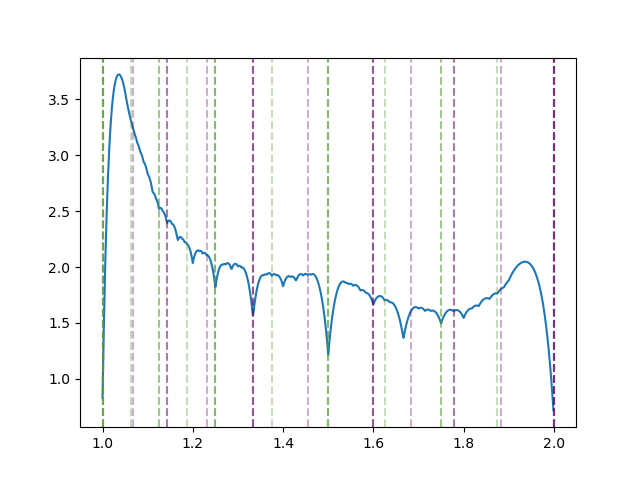

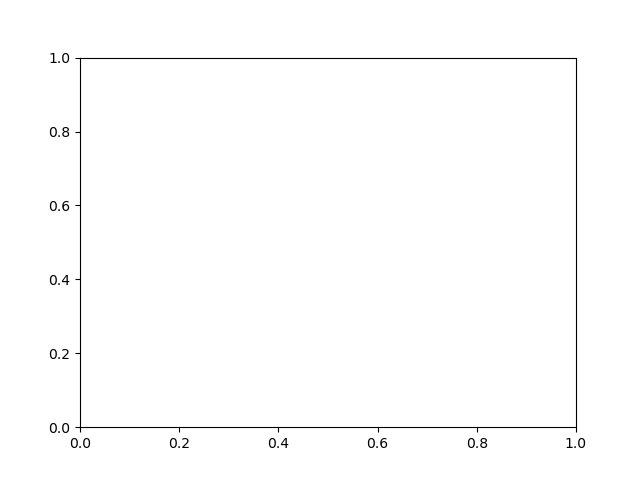

In [6]:
plt.cla()
plt.figure()
plt.plot(X, Y)
for f in ref_f:
    # place f between 1 and 2 on the x-axis
    f = f / start
    while f >= 2:
        f = f / 2
    plt.axvline(x=f, color='#5935', linestyle='--')
    # and inverted (1.5 => 1.33)
    plt.axvline(x=2/f, color='#6165', linestyle='--')
plt.show()

In [7]:
def dissonance_ratio( ratio, fundamental_hz=440, harmonics=20 ):
    f0, a0 = generate_harmonics_jax( fundamental_hz, harmonics=harmonics )
    f1, a1 = generate_harmonics_jax( fundamental_hz * ratio, harmonics=harmonics )
    return dissonance_jax(jnp.concatenate([f0, f1]), jnp.concatenate([a0, a1]))

def dissonance_chord( new_fund, chord_f, chord_a, harmonics=20 ):
    f0, a0 = generate_harmonics_jax( new_fund, harmonics=harmonics )
    return dissonance_jax(jnp.concatenate([f0, chord_f]), jnp.concatenate([a0, chord_a]))

In [8]:
dDr = grad(dissonance_ratio)
def optimise_ratio( initial_ratio, lr=LEARNING_RATE, steps=1000, decay=DECAY, momentum=MOMENTUM ):
    ratio_list = []
    ratio = initial_ratio
    v = 0
    for _ in range(steps):
        g = dDr(ratio)
        v = momentum * v - lr * g
        ratio += v
        lr *= decay

        # early stopping rules
        def print_stop( reason ):
            print(f"[{reason}] step: {_} v: {v:.6e} ratio: {ratio:.6f} g: {g:.6e}")

        if ratio < 1 or ratio > 2:
            if ratio < 1:
                ratio = 1
            else:
                ratio = 2
            print_stop("out of bounds")
            break

        if abs(v) < 1e-9:
            print_stop("low velocity")
            break
        ratio_list.append(ratio)
    return ratio, ratio_list

In [9]:
initial_ratio = random() + 1
final_ratio, trail = optimise_ratio( initial_ratio )

[low velocity] step: 96 v: -1.823146e-10 ratio: 1.166667 g: 1.109055e+01


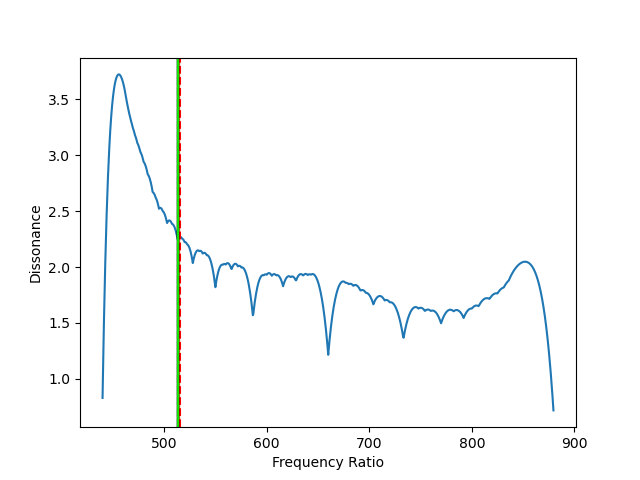

In [10]:
X_hz = np.array(X) * start
initial_hz = start * initial_ratio
final_hz = start * final_ratio

plt.figure()
plt.plot(X_hz, Y)
plt.axvline(x=initial_hz, color='red', linestyle='--', label='Initial Ratio')
plt.axvline(x=final_hz, color='green', linestyle='--', label='Optimized Ratio')
for i, t in enumerate(trail):
    alpha = 0.1
    # color red -> green
    red = 1 - i / len(trail)
    green = i / len(trail)
    plt.axvline(x=start * t, color=(red, green, 0, alpha), linestyle='-')
plt.xlabel('Frequency Ratio')
plt.ylabel('Dissonance')
plt.show()

In [11]:
def equal_temperament_ratio( n, system_base=12 ):
    if n < 1:
        return 1.0
    n %= system_base
    return 2 ** (n / system_base)

def equal_temperament_name( n ):
    names = ['m2', 'M2', 'm3', 'M3', '4P', 'A4/d5', '5P', 'm6', 'M6', 'm7', 'M7']
    if n < 1:
        return names[0]
    n %= len(names)
    return names[n]

In [12]:
# equal temperament optimization
equal_temps = [equal_temperament_ratio(n) for n in range(1, 12)]

equal_opts = []
for et in equal_temps:
    opt, _ = optimise_ratio( et )
    equal_opts.append(opt)

[low velocity] step: 150 v: 9.053840e-10 ratio: 1.105688 g: -1.469751e+01
[low velocity] step: 146 v: -9.283475e-10 ratio: 1.142882 g: 9.887619e+00
[low velocity] step: 153 v: -9.663448e-10 ratio: 1.200000 g: 2.152000e+01
[low velocity] step: 156 v: -9.400644e-10 ratio: 1.250000 g: 2.871550e+01
[low velocity] step: 101 v: -8.267378e-10 ratio: 1.333333 g: -4.108826e+01
[low velocity] step: 137 v: -9.370602e-10 ratio: 1.416667 g: 3.866676e+00
[low velocity] step: 120 v: -7.769181e-10 ratio: 1.500000 g: -5.048744e+01
[low velocity] step: 147 v: -9.345479e-10 ratio: 1.600000 g: 1.105969e+01
[low velocity] step: 154 v: -9.658410e-10 ratio: 1.666667 g: 2.389746e+01
[low velocity] step: 136 v: -9.792454e-10 ratio: 1.777778 g: 3.636650e+00
[low velocity] step: 139 v: -9.404835e-10 ratio: 1.879575 g: 4.791041e+00


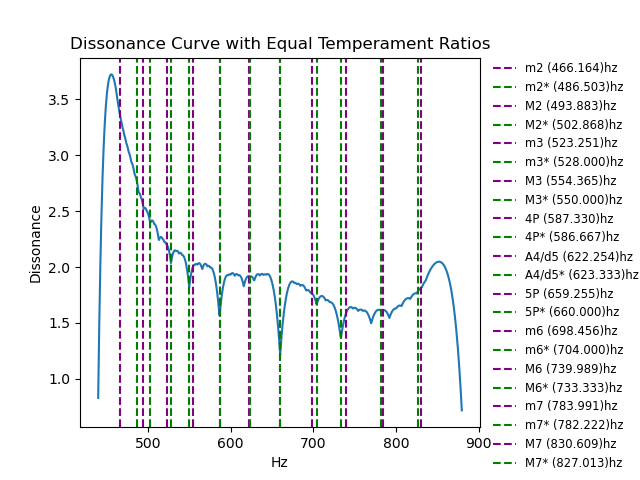

In [13]:
# plot the equal temperament ratios on the dissonance curve
plt.figure()
plt.plot(X_hz, Y)
for i, (f, fo) in enumerate(zip(equal_temps, equal_opts)):
    f_hz = start * f
    fo_hz = start * fo
    plt.axvline(x=f_hz, color='purple', linestyle='--', label=f"{equal_temperament_name(i)} ({f_hz:.3f})hz")
    plt.axvline(x=fo_hz, color='green', linestyle='--', label=f"{equal_temperament_name(i)}* ({fo_hz:.3f})hz")
plt.legend(loc='upper left', fontsize='small', bbox_to_anchor=(1.02, 1), borderaxespad=0, frameon=False)
plt.subplots_adjust(right=0.75)
plt.xlabel('Hz')
plt.ylabel('Dissonance')
plt.title('Dissonance Curve with Equal Temperament Ratios')
plt.show()